# Dokumentasi Pengujian Preprocessing
## Bab 6.1.2.1 — BiLSTM Piano Hand Gesture Recognition

Notebook ini menghasilkan gambar dan tabel dokumentasi untuk:
- **Gambar 6.X** — Deteksi 21 landmark tangan dengan MediaPipe Hands
- **Gambar 6.Y** — Visualisasi Angle Feature (10 sudut antar sendi)
- **Gambar 6.Z** — Visualisasi Distance Feature (10 jarak antar ujung jari)
- **Gambar 6.W** — Ilustrasi Sliding Window Sequence (30 frame, stride 5)

In [3]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
import os

OUTPUT_DIR = "dokumentasi_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

# Cari satu video dari dataset sebagai sample
SAMPLE_VIDEO = "Dataset/needs_improvement\IMG_6003.MOV"


print("Sample video:", SAMPLE_VIDEO)


Sample video: Dataset/needs_improvement\IMG_6003.MOV


---
## Gambar 6.X — Deteksi 21 Landmark Tangan dengan MediaPipe Hands

In [20]:
# Ambil beberapa frame dari video, tampilkan yang berhasil dideteksi
cap = cv2.VideoCapture(SAMPLE_VIDEO)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Coba ambil frame dari posisi 25%, 50%, 75% video
candidate_positions = [
    int(total_frames * 0.10),
    int(total_frames * 0.25),
    int(total_frames * 0.40),
    int(total_frames * 0.55),
    int(total_frames * 0.70),
]

detected_frames = []  # list of (frame_rgb, hand_landmarks, frame_idx)

with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
) as hands:
    for pos in candidate_positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
        ret, frame = cap.read()
        if not ret:
            continue
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(frame_rgb)
        if results.multi_hand_landmarks:
            detected_frames.append((frame_rgb.copy(), results.multi_hand_landmarks[0], pos))
        if len(detected_frames) >= 3:
            break

cap.release()
print(f"Frame terdeteksi: {len(detected_frames)}")

D:\anaconda3\envs\tugas-akhir\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Frame terdeteksi: 3


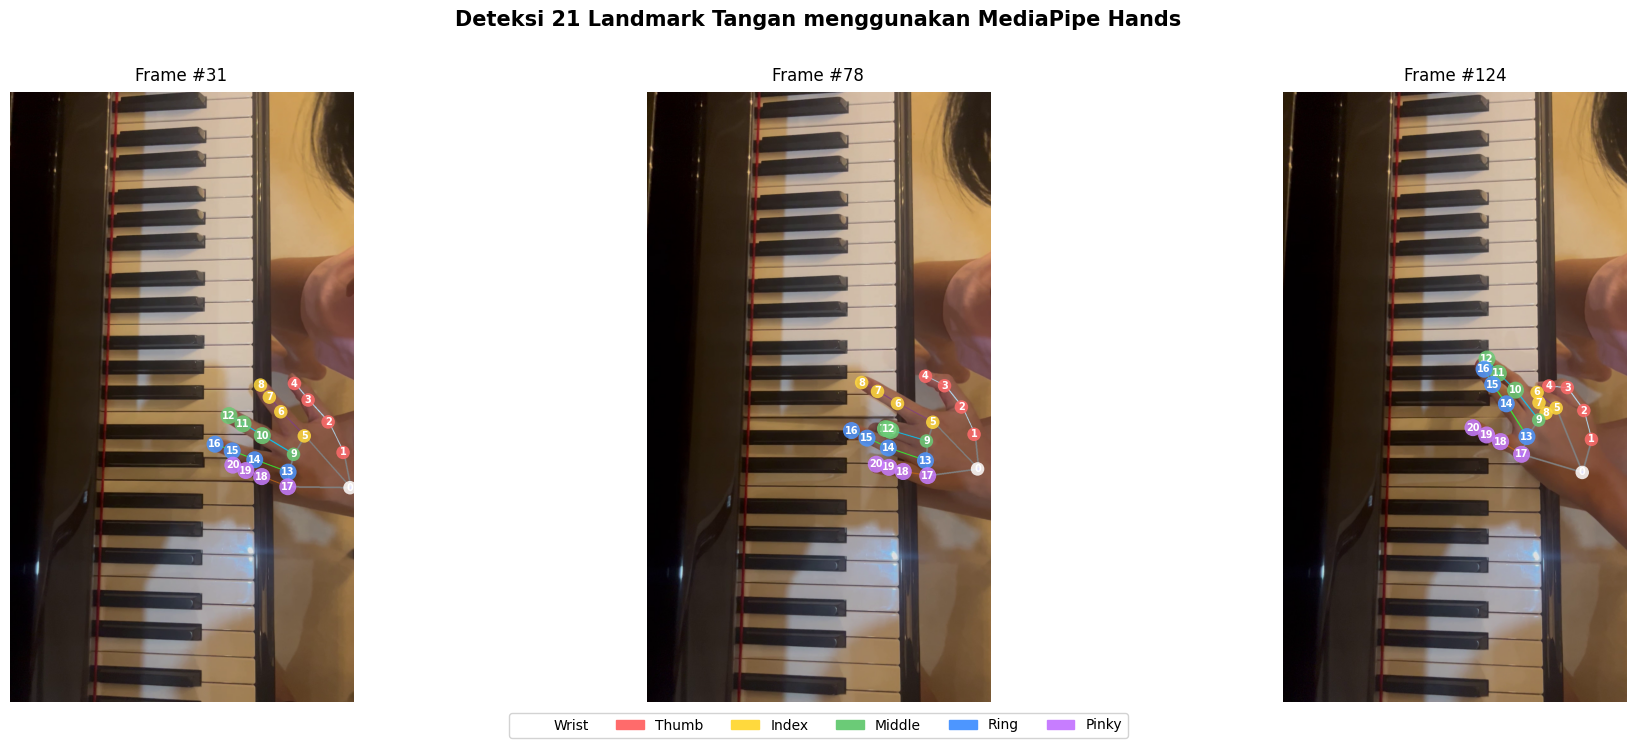

Tersimpan: dokumentasi_output\gambar_6X_landmark_detection.png


In [21]:
LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP"
]

# Warna per kelompok jari
FINGER_COLORS = {
    "WRIST":  "#FFFFFF",
    "THUMB":  "#FF6B6B",
    "INDEX":  "#FFD93D",
    "MIDDLE": "#6BCB77",
    "RING":   "#4D96FF",
    "PINKY":  "#C77DFF",
}

def get_color(name):
    for key in FINGER_COLORS:
        if name.startswith(key):
            return FINGER_COLORS[key]
    return FINGER_COLORS["WRIST"]

n_show = len(detected_frames)
fig, axes = plt.subplots(1, n_show, figsize=(7 * n_show, 7))
if n_show == 1:
    axes = [axes]

for ax, (frame_rgb, hand_lm, frame_idx) in zip(axes, detected_frames):
    # Gambar frame dengan drawing_utils standar
    annotated = frame_rgb.copy()
    mp_draw.draw_landmarks(
        annotated,
        hand_lm,
        mp_hands.HAND_CONNECTIONS,
        mp_styles.get_default_hand_landmarks_style(),
        mp_styles.get_default_hand_connections_style()
    )

    h, w, _ = annotated.shape
    ax.imshow(annotated)

    # Tambahkan label nomor landmark
    for idx, lm in enumerate(hand_lm.landmark):
        px, py = int(lm.x * w), int(lm.y * h)
        color = get_color(LANDMARK_NAMES[idx])
        ax.annotate(
            str(idx),
            xy=(px, py),
            fontsize=7,
            fontweight="bold",
            color="white",
            ha="center", va="center",
            bbox=dict(boxstyle="circle,pad=0.18", fc=color, ec="none", alpha=0.85)
        )

    ax.set_title(f"Frame #{frame_idx}", fontsize=12, pad=8)
    ax.axis("off")

# Legend warna per jari
legend_patches = [
    mpatches.Patch(color=c, label=f.capitalize())
    for f, c in FINGER_COLORS.items()
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=6,
    fontsize=10,
    framealpha=0.85,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle(
    "Deteksi 21 Landmark Tangan menggunakan MediaPipe Hands",
    fontsize=15, fontweight="bold", y=1.01
)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gambar_6X_landmark_detection.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Tersimpan:", out_path)

---
## Gambar 6.Y — Visualisasi Angle Feature (10 Sudut Antar Sendi)

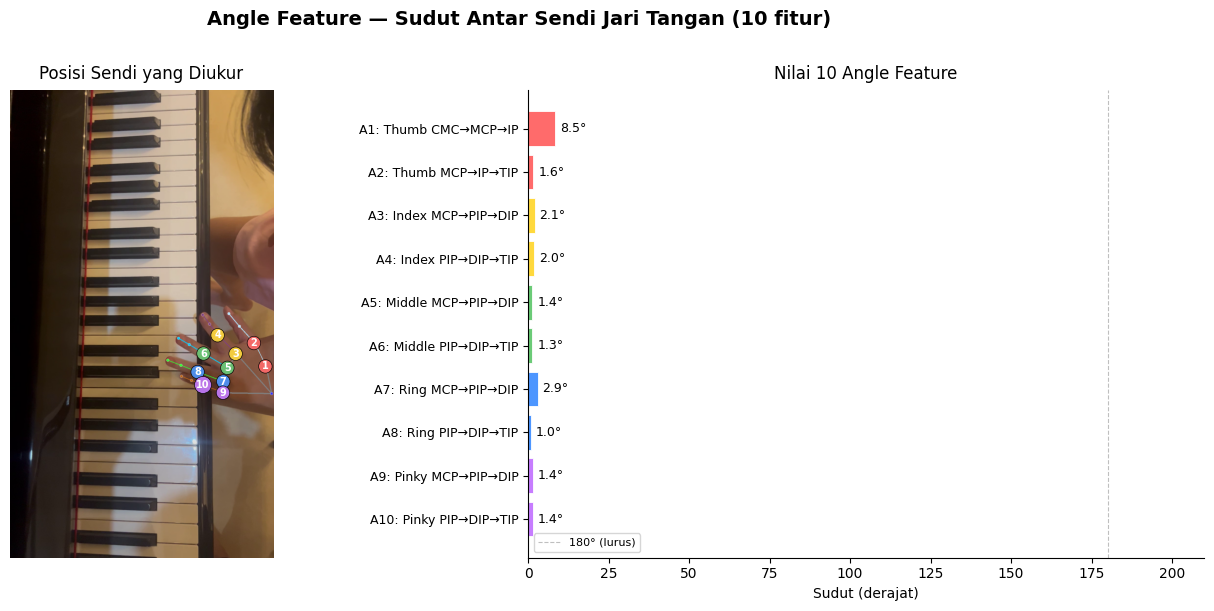

Tersimpan: dokumentasi_output\gambar_6Y_angle_feature.png


In [22]:
# Definisi JOINTS sama dengan kode utama
JOINTS = [
    [2,  1,  3],   # Thumb: CMC-MCP-IP
    [3,  2,  4],   # Thumb: MCP-IP-TIP
    [6,  5,  7],   # Index: MCP-PIP-DIP
    [7,  6,  8],   # Index: PIP-DIP-TIP
    [10, 9, 11],   # Middle: MCP-PIP-DIP
    [11,10, 12],   # Middle: PIP-DIP-TIP
    [14,13, 15],   # Ring: MCP-PIP-DIP
    [15,14, 16],   # Ring: PIP-DIP-TIP
    [18,17, 19],   # Pinky: MCP-PIP-DIP
    [19,18, 20],   # Pinky: PIP-DIP-TIP
]

JOINT_LABELS = [
    "Thumb CMC→MCP→IP",
    "Thumb MCP→IP→TIP",
    "Index MCP→PIP→DIP",
    "Index PIP→DIP→TIP",
    "Middle MCP→PIP→DIP",
    "Middle PIP→DIP→TIP",
    "Ring MCP→PIP→DIP",
    "Ring PIP→DIP→TIP",
    "Pinky MCP→PIP→DIP",
    "Pinky PIP→DIP→TIP",
]

JOINT_COLORS = [
    "#FF6B6B", "#FF6B6B",
    "#FFD93D", "#FFD93D",
    "#6BCB77", "#6BCB77",
    "#4D96FF", "#4D96FF",
    "#C77DFF", "#C77DFF",
]

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

# Hitung sudut dari frame pertama yang terdeteksi
frame_rgb, hand_lm, _ = detected_frames[0]
coords = np.array([[lm.x, lm.y, lm.z] for lm in hand_lm.landmark])
h_img, w_img, _ = frame_rgb.shape

angles = []
for joint in JOINTS:
    angles.append(calculate_angle(coords[joint[0]], coords[joint[1]], coords[joint[2]]))

# ── Panel kiri: gambar tangan dengan arc sudut ──────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(14, 6),
                                      gridspec_kw={"width_ratios": [1, 1.1]})

annotated = frame_rgb.copy()
mp_draw.draw_landmarks(
    annotated, hand_lm, mp_hands.HAND_CONNECTIONS,
    mp_styles.get_default_hand_landmarks_style(),
    mp_styles.get_default_hand_connections_style()
)
ax_img.imshow(annotated)
ax_img.axis("off")
ax_img.set_title("Posisi Sendi yang Diukur", fontsize=12, pad=8)

for i, (joint, color) in enumerate(zip(JOINTS, JOINT_COLORS)):
    p1 = coords[joint[0]]
    p2 = coords[joint[1]]  # titik tengah (vertex)
    p3 = coords[joint[2]]

    px1 = (int(p1[0]*w_img), int(p1[1]*h_img))
    px2 = (int(p2[0]*w_img), int(p2[1]*h_img))
    px3 = (int(p3[0]*w_img), int(p3[1]*h_img))

    # Nomor joint di titik vertex
    ax_img.annotate(
        str(i+1),
        xy=px2, fontsize=7, fontweight="bold", color="white", ha="center", va="center",
        bbox=dict(boxstyle="circle,pad=0.18", fc=color, ec="black", lw=0.5, alpha=0.9)
    )

# ── Panel kanan: bar chart sudut ────────────────────────────────────────────
y_pos = np.arange(len(angles))
bars = ax_bar.barh(y_pos, angles, color=JOINT_COLORS, edgecolor="white", linewidth=0.6)

for bar, angle in zip(bars, angles):
    ax_bar.text(
        bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
        f"{angle:.1f}°", va="center", ha="left", fontsize=9
    )

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels([f"A{i+1}: {lbl}" for i, lbl in enumerate(JOINT_LABELS)], fontsize=9)
ax_bar.set_xlabel("Sudut (derajat)", fontsize=10)
ax_bar.set_title("Nilai 10 Angle Feature", fontsize=12, pad=8)
ax_bar.set_xlim(0, 210)
ax_bar.invert_yaxis()
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.axvline(180, color="gray", linestyle="--", linewidth=0.8, alpha=0.5, label="180° (lurus)")
ax_bar.legend(fontsize=8)

fig.suptitle(
    "Angle Feature — Sudut Antar Sendi Jari Tangan (10 fitur)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gambar_6Y_angle_feature.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Tersimpan:", out_path)

---
## Gambar 6.Z — Visualisasi Distance Feature (10 Jarak Antar Ujung Jari)

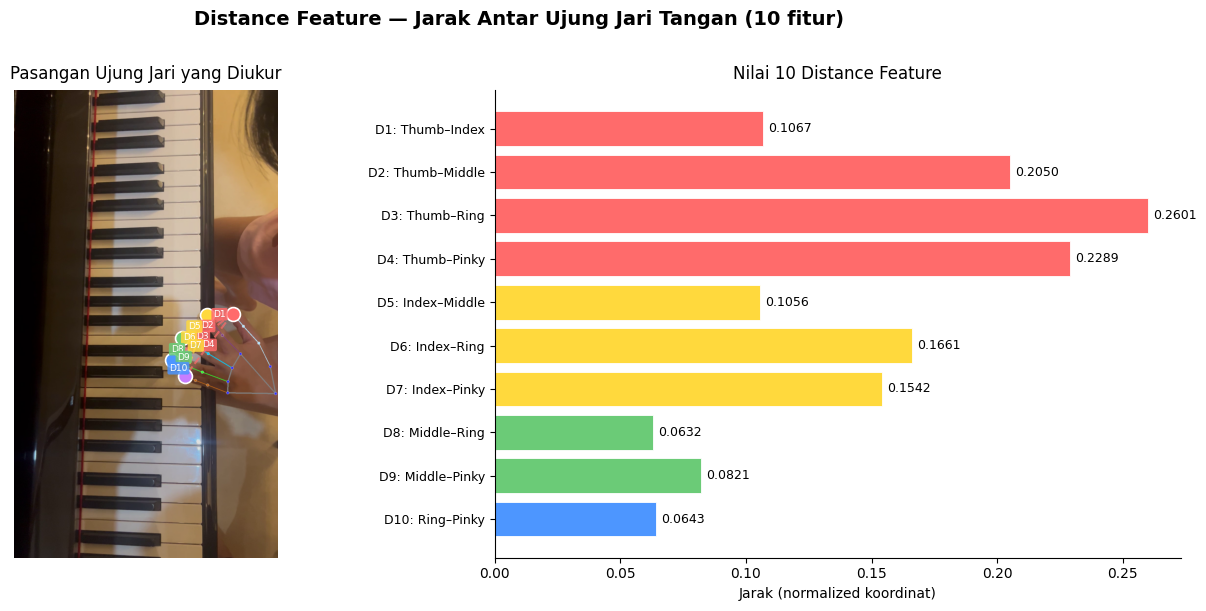

Tersimpan: dokumentasi_output\gambar_6Z_distance_feature.png


In [23]:
FINGERTIPS = [4, 8, 12, 16, 20]
FINGERTIP_NAMES = ["Thumb", "Index", "Middle", "Ring", "Pinky"]
TIP_COLORS = ["#FF6B6B", "#FFD93D", "#6BCB77", "#4D96FF", "#C77DFF"]

dist_pairs = []
dist_labels = []
dist_colors = []
distances = []

for i in range(len(FINGERTIPS)):
    for j in range(i + 1, len(FINGERTIPS)):
        p1 = coords[FINGERTIPS[i]]
        p2 = coords[FINGERTIPS[j]]
        d = np.linalg.norm(p1 - p2)
        dist_pairs.append((FINGERTIPS[i], FINGERTIPS[j]))
        dist_labels.append(f"D{len(distances)+1}: {FINGERTIP_NAMES[i]}–{FINGERTIP_NAMES[j]}")
        # Warna campuran kedua ujung jari
        dist_colors.append(TIP_COLORS[i])
        distances.append(d)

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(14, 6),
                                      gridspec_kw={"width_ratios": [1, 1.1]})

# ── Panel kiri: gambar tangan + garis jarak ─────────────────────────────────
annotated2 = frame_rgb.copy()
mp_draw.draw_landmarks(
    annotated2, hand_lm, mp_hands.HAND_CONNECTIONS,
    mp_styles.get_default_hand_landmarks_style(),
    mp_styles.get_default_hand_connections_style()
)
ax_img.imshow(annotated2)
ax_img.axis("off")
ax_img.set_title("Pasangan Ujung Jari yang Diukur", fontsize=12, pad=8)

for k, (ti, tj) in enumerate(dist_pairs):
    p1 = coords[ti]
    p2 = coords[tj]
    px1 = (p1[0]*w_img, p1[1]*h_img)
    px2 = (p2[0]*w_img, p2[1]*h_img)

    ax_img.plot(
        [px1[0], px2[0]], [px1[1], px2[1]],
        color=dist_colors[k], linewidth=1.5, alpha=0.7, linestyle="--"
    )

    mid_x = (px1[0] + px2[0]) / 2
    mid_y = (px1[1] + px2[1]) / 2
    ax_img.annotate(
        f"D{k+1}",
        xy=(mid_x, mid_y), fontsize=6.5, color="white", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc=dist_colors[k], ec="none", alpha=0.85)
    )

# Tandai ujung jari dengan lingkaran besar
for i, tip_idx in enumerate(FINGERTIPS):
    px = coords[tip_idx][0] * w_img
    py = coords[tip_idx][1] * h_img
    ax_img.plot(px, py, "o", ms=10, color=TIP_COLORS[i],
                markeredgecolor="white", markeredgewidth=1.2)

# ── Panel kanan: bar chart jarak ─────────────────────────────────────────────
y_pos = np.arange(len(distances))
bars = ax_bar.barh(y_pos, distances, color=dist_colors, edgecolor="white", linewidth=0.6)

for bar, d in zip(bars, distances):
    ax_bar.text(
        bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
        f"{d:.4f}", va="center", ha="left", fontsize=9
    )

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(dist_labels, fontsize=9)
ax_bar.set_xlabel("Jarak (normalized koordinat)", fontsize=10)
ax_bar.set_title("Nilai 10 Distance Feature", fontsize=12, pad=8)
ax_bar.invert_yaxis()
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

fig.suptitle(
    "Distance Feature — Jarak Antar Ujung Jari Tangan (10 fitur)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gambar_6Z_distance_feature.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Tersimpan:", out_path)

---
## Gambar 6.W — Ilustrasi Sliding Window Sequence (30 frame, stride 5)

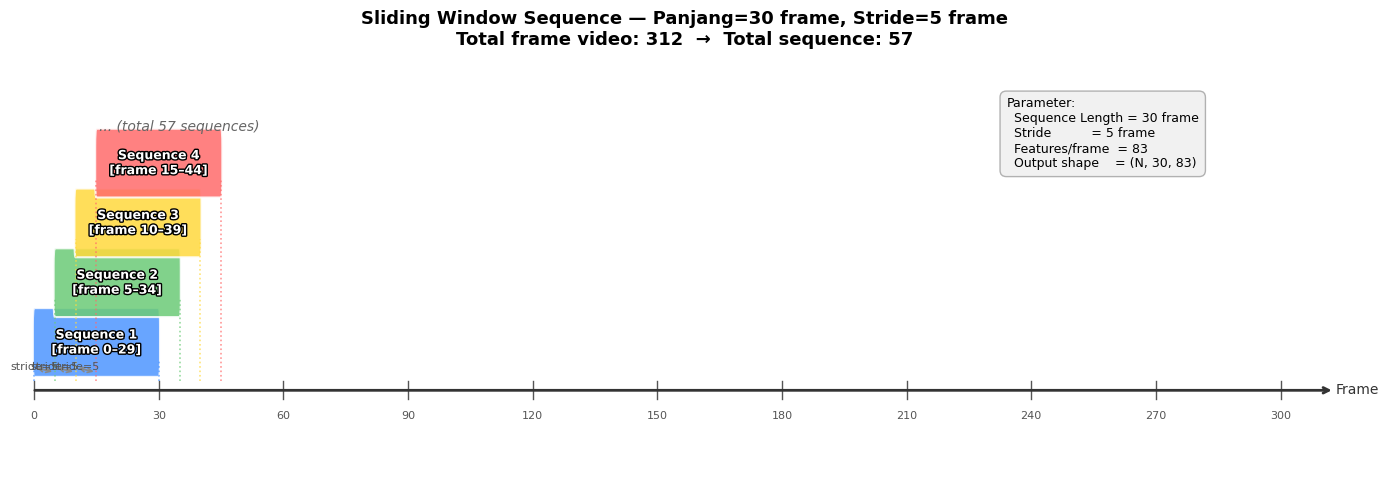

Tersimpan: dokumentasi_output\gambar_6W_sliding_window.png


In [24]:
SEQ_LEN = 30
STRIDE  = 5
N_SHOW  = 4   # jumlah window yang ditampilkan

# Simulasi total frame dari video
cap_tmp = cv2.VideoCapture(SAMPLE_VIDEO)
TOTAL_FRAMES = int(cap_tmp.get(cv2.CAP_PROP_FRAME_COUNT))
cap_tmp.release()

# Hitung posisi window
windows = []
i = 0
while i + SEQ_LEN <= TOTAL_FRAMES:
    windows.append((i, i + SEQ_LEN - 1))
    i += STRIDE

N_WINDOWS = len(windows)

# ── Gambar ilustrasi ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(-1, TOTAL_FRAMES + 2)
ax.set_ylim(-1.5, N_SHOW + 1.5)
ax.axis("off")
ax.set_title(
    f"Sliding Window Sequence — Panjang={SEQ_LEN} frame, Stride={STRIDE} frame\n"
    f"Total frame video: {TOTAL_FRAMES}  →  Total sequence: {N_WINDOWS}",
    fontsize=13, fontweight="bold", pad=12
)

# Garis timeline
ax.annotate(
    "", xy=(TOTAL_FRAMES + 1, 0), xytext=(-0.5, 0),
    arrowprops=dict(arrowstyle="->", color="#333333", lw=2)
)
ax.text(TOTAL_FRAMES + 1.2, 0, "Frame", va="center", fontsize=10, color="#333333")

# Tick marks setiap 30 frame
for t in range(0, TOTAL_FRAMES + 1, 30):
    ax.plot([t, t], [-0.15, 0.15], color="#555555", lw=1)
    ax.text(t, -0.35, str(t), ha="center", va="top", fontsize=8, color="#555555")

# Warna per window yang ditampilkan
PALETTE = ["#4D96FF", "#6BCB77", "#FFD93D", "#FF6B6B"]

for row, (win_start, win_end) in enumerate(windows[:N_SHOW]):
    color = PALETTE[row % len(PALETTE)]
    y_center = row + 0.8
    height = 0.55

    # Kotak window
    rect = mpatches.FancyBboxPatch(
        (win_start, y_center - height/2), SEQ_LEN, height,
        boxstyle="round,pad=0.3",
        linewidth=1.5, edgecolor="white",
        facecolor=color, alpha=0.85
    )
    ax.add_patch(rect)

    # Label di dalam kotak
    ax.text(
        win_start + SEQ_LEN/2, y_center,
        f"Sequence {row+1}\n[frame {win_start}–{win_end}]",
        ha="center", va="center", fontsize=9, fontweight="bold",
        color="white",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")]
    )

    # Garis putus-putus ke timeline
    ax.plot([win_start, win_start], [0.15, y_center - height/2],
            color=color, lw=1.2, linestyle=":", alpha=0.7)
    ax.plot([win_end+1, win_end+1], [0.15, y_center - height/2],
            color=color, lw=1.2, linestyle=":", alpha=0.7)

    # Anotasi stride
    if row < N_SHOW - 1:
        next_start = windows[row+1][0]
        ax.annotate(
            f"stride={STRIDE}",
            xy=(next_start, 0.3), xytext=(win_start, 0.3),
            arrowprops=dict(arrowstyle="<->", color="#888", lw=1.2),
            ha="center", va="bottom", fontsize=8, color="#555"
        )

# Ellipsis jika masih ada window berikutnya
if N_WINDOWS > N_SHOW:
    ax.text(
        windows[N_SHOW][0] + SEQ_LEN/2, N_SHOW + 0.4,
        f"... (total {N_WINDOWS} sequences)",
        ha="center", va="center", fontsize=10,
        style="italic", color="#666666"
    )

# Info box
info_text = (
    f"Parameter:\n"
    f"  Sequence Length = {SEQ_LEN} frame\n"
    f"  Stride          = {STRIDE} frame\n"
    f"  Features/frame  = 83\n"
    f"  Output shape    = (N, {SEQ_LEN}, 83)"
)
ax.text(
    TOTAL_FRAMES * 0.75, N_SHOW + 0.9,
    info_text, fontsize=9, va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.5", fc="#F0F0F0", ec="#AAAAAA", alpha=0.9)
)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gambar_6W_sliding_window.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Tersimpan:", out_path)

---
## Tabel — Ringkasan Fitur Hasil Preprocessing

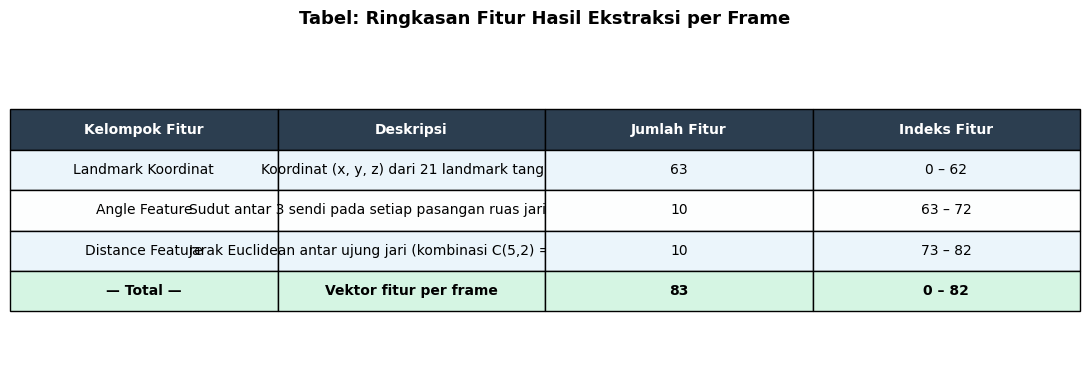

Tersimpan: dokumentasi_output\tabel_ringkasan_fitur.png


In [25]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

columns = ["Kelompok Fitur", "Deskripsi", "Jumlah Fitur", "Indeks Fitur"]
rows = [
    ["Landmark Koordinat",
     "Koordinat (x, y, z) dari 21 landmark tangan",
     "63",
     "0 – 62"],
    ["Angle Feature",
     "Sudut antar 3 sendi pada setiap pasangan ruas jari (10 pasang)",
     "10",
     "63 – 72"],
    ["Distance Feature",
     "Jarak Euclidean antar ujung jari (kombinasi C(5,2) = 10 pasang)",
     "10",
     "73 – 82"],
    ["\u2014 Total \u2014",
     "Vektor fitur per frame",
     "83",
     "0 – 82"],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header style
for j in range(len(columns)):
    table[0, j].set_facecolor("#2C3E50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Row style
row_colors = ["#EBF5FB", "#FDFEFE", "#EBF5FB", "#D5F5E3"]
for i, color in enumerate(row_colors):
    for j in range(len(columns)):
        table[i+1, j].set_facecolor(color)
        if i == len(rows) - 1:
            table[i+1, j].set_text_props(fontweight="bold")

ax.set_title(
    "Tabel: Ringkasan Fitur Hasil Ekstraksi per Frame",
    fontsize=13, fontweight="bold", pad=12
)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "tabel_ringkasan_fitur.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Tersimpan:", out_path)

---
## Ringkasan Output

In [26]:
print("=" * 55)
print("  FILE DOKUMENTASI YANG DIHASILKAN")
print("=" * 55)
for f in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {f:<45}  ({size_kb:.1f} KB)")
print("=" * 55)

  FILE DOKUMENTASI YANG DIHASILKAN
  .ipynb_checkpoints                             (0.0 KB)
  gambar_6W_sliding_window.png                   (138.4 KB)
  gambar_6X_landmark_detection.png               (2205.9 KB)
  gambar_6Y_angle_feature.png                    (608.8 KB)
  gambar_6Z_distance_feature.png                 (605.2 KB)
  tabel_ringkasan_fitur.png                      (83.1 KB)


---
## Gambar 6.A — Deteksi Tangan pada Gambar Statis + Angle Feature

In [4]:
# ============================================================
# KONFIGURASI — ganti path sesuai lokasi gambar yang disimpan
# ============================================================
IMAGE_PATH = "sample_piano.jpg"

# ============================================================
# LOAD & DETEKSI TANGAN
# ============================================================
img_bgr = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, f"Gambar tidak ditemukan: {IMAGE_PATH}"

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h_img, w_img = img_rgb.shape[:2]

with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5
) as hands:
    results = hands.process(img_rgb)

n_detected = len(results.multi_hand_landmarks) if results.multi_hand_landmarks else 0
print(f"Jumlah tangan terdeteksi: {n_detected}")

if n_detected == 0:
    print("Tidak ada tangan terdeteksi. Coba turunkan min_detection_confidence.")

Jumlah tangan terdeteksi: 1


D:\anaconda3\envs\tugas-akhir\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


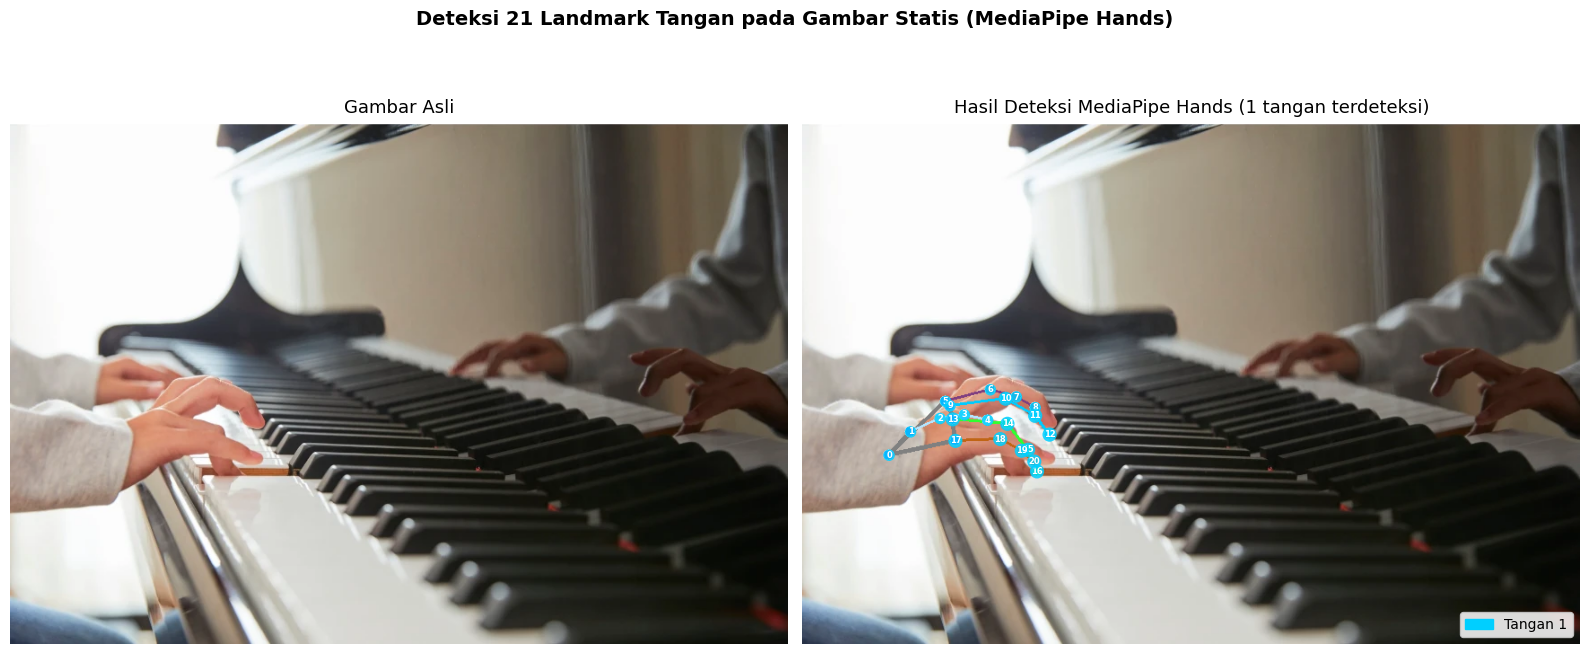

Tersimpan: dokumentasi_output\gambar_6A_static_landmark.png


In [5]:
# ============================================================
# PANEL 1 — Gambar asli vs gambar dengan landmark
# ============================================================
HAND_PALETTE = ["#00CFFF", "#FF6B6B"]   # warna per tangan (tangan 1, tangan 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- kiri: gambar asli ---
axes[0].imshow(img_rgb)
axes[0].set_title("Gambar Asli", fontsize=13, pad=8)
axes[0].axis("off")

# --- kanan: hasil deteksi ---
annotated = img_rgb.copy()

if results.multi_hand_landmarks:
    for hand_lm in results.multi_hand_landmarks:
        mp_draw.draw_landmarks(
            annotated,
            hand_lm,
            mp_hands.HAND_CONNECTIONS,
            mp_styles.get_default_hand_landmarks_style(),
            mp_styles.get_default_hand_connections_style()
        )

axes[1].imshow(annotated)
axes[1].set_title(
    f"Hasil Deteksi MediaPipe Hands ({n_detected} tangan terdeteksi)",
    fontsize=13, pad=8
)
axes[1].axis("off")

# Tambah nomor landmark dan nama untuk setiap tangan
if results.multi_hand_landmarks:
    for hand_idx, hand_lm in enumerate(results.multi_hand_landmarks):
        color = HAND_PALETTE[hand_idx % len(HAND_PALETTE)]
        for lm_idx, lm in enumerate(hand_lm.landmark):
            px = int(lm.x * w_img)
            py = int(lm.y * h_img)
            axes[1].annotate(
                str(lm_idx),
                xy=(px, py),
                fontsize=6,
                fontweight="bold",
                color="white",
                ha="center", va="center",
                bbox=dict(
                    boxstyle="circle,pad=0.15",
                    fc=color, ec="none", alpha=0.85
                )
            )

# Legend tangan
legend_patches = [
    mpatches.Patch(color=HAND_PALETTE[i], label=f"Tangan {i+1}")
    for i in range(n_detected)
]
if legend_patches:
    axes[1].legend(
        handles=legend_patches,
        loc="lower right", fontsize=10,
        framealpha=0.85
    )

fig.suptitle(
    "Deteksi 21 Landmark Tangan pada Gambar Statis (MediaPipe Hands)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gambar_6A_static_landmark.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Tersimpan:", out_path)

In [6]:
# ============================================================
# HITUNG ANGLE FEATURE untuk setiap tangan yang terdeteksi
# ============================================================
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

JOINTS = [
    [2,  1,  3],
    [3,  2,  4],
    [6,  5,  7],
    [7,  6,  8],
    [10, 9,  11],
    [11, 10, 12],
    [14, 13, 15],
    [15, 14, 16],
    [18, 17, 19],
    [19, 18, 20],
]

JOINT_LABELS = [
    "A1  Thumb   CMC→MCP→IP",
    "A2  Thumb   MCP→IP→TIP",
    "A3  Index   MCP→PIP→DIP",
    "A4  Index   PIP→DIP→TIP",
    "A5  Middle  MCP→PIP→DIP",
    "A6  Middle  PIP→DIP→TIP",
    "A7  Ring    MCP→PIP→DIP",
    "A8  Ring    PIP→DIP→TIP",
    "A9  Pinky   MCP→PIP→DIP",
    "A10 Pinky   PIP→DIP→TIP",
]

JOINT_COLORS = [
    "#FF6B6B", "#FF6B6B",
    "#FFD93D", "#FFD93D",
    "#6BCB77", "#6BCB77",
    "#4D96FF", "#4D96FF",
    "#C77DFF", "#C77DFF",
]

all_hand_data = []   # list of dict per tangan

if results.multi_hand_landmarks and results.multi_handedness:
    for hand_idx, (hand_lm, handedness) in enumerate(
        zip(results.multi_hand_landmarks, results.multi_handedness)
    ):
        hand_label = handedness.classification[0].label   # "Left" / "Right"
        coords = np.array([[lm.x, lm.y, lm.z] for lm in hand_lm.landmark])
        angles = [
            calculate_angle(coords[j[0]], coords[j[1]], coords[j[2]])
            for j in JOINTS
        ]
        all_hand_data.append({
            "idx":    hand_idx,
            "label":  hand_label,
            "coords": coords,
            "angles": angles,
            "lm":     hand_lm,
        })
        print(f"\nTangan {hand_idx+1} ({hand_label})")
        for name, angle in zip(JOINT_LABELS, angles):
            print(f"  {name:35s} = {angle:6.2f}°")


Tangan 1 (Left)
  A1  Thumb   CMC→MCP→IP              =  10.03°
  A2  Thumb   MCP→IP→TIP              =  14.78°
  A3  Index   MCP→PIP→DIP             =  16.04°
  A4  Index   PIP→DIP→TIP             =   9.60°
  A5  Middle  MCP→PIP→DIP             =  21.50°
  A6  Middle  PIP→DIP→TIP             =   8.81°
  A7  Ring    MCP→PIP→DIP             =  24.69°
  A8  Ring    PIP→DIP→TIP             =   6.37°
  A9  Pinky   MCP→PIP→DIP             =  15.99°
  A10 Pinky   PIP→DIP→TIP             =   5.86°


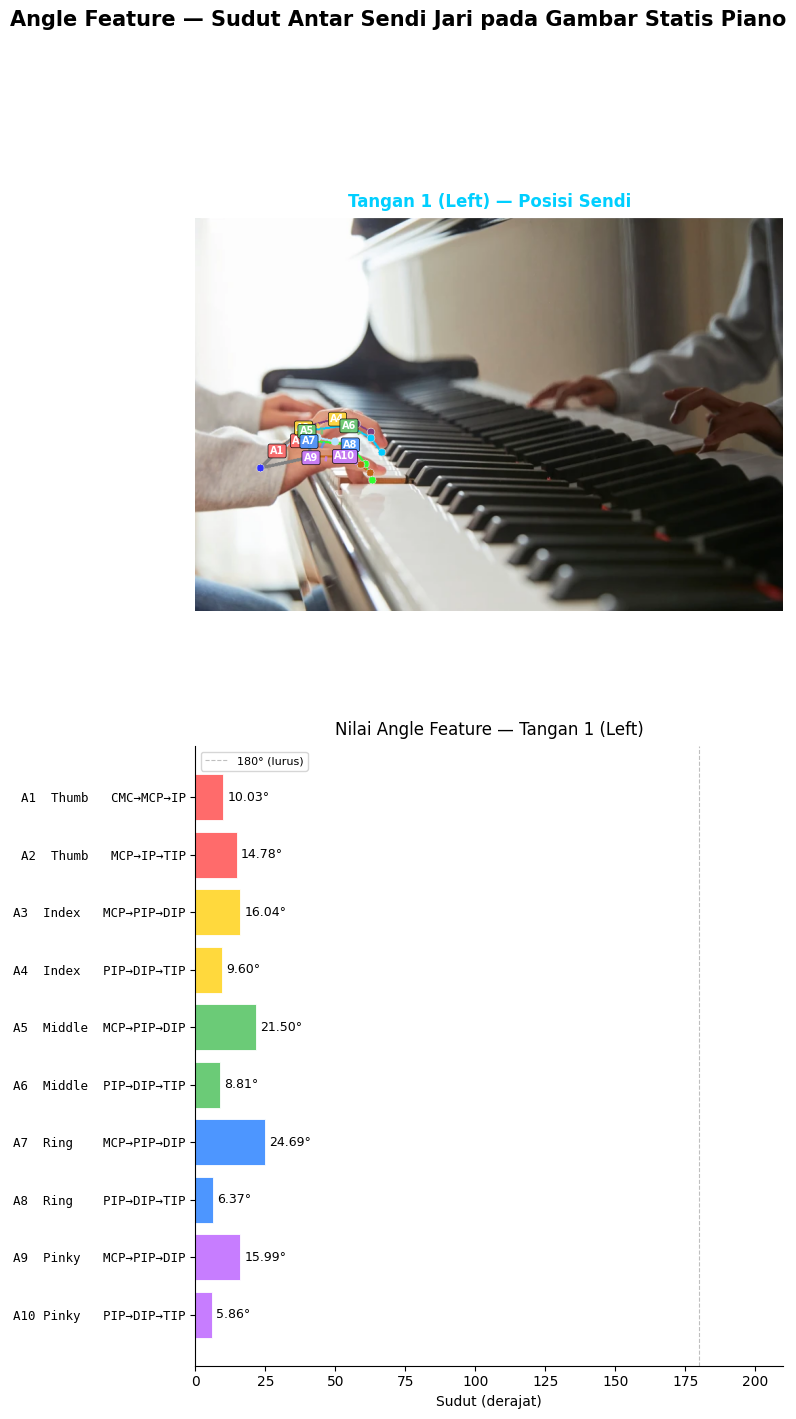

Tersimpan: dokumentasi_output\gambar_6A_angle_feature_static.png


In [7]:
# ============================================================
# PANEL 2 — Visualisasi Angle Feature per Tangan
# Baris atas : gambar tangan + nomor vertex sendi
# Baris bawah: bar chart nilai sudut
# ============================================================
n_hands = len(all_hand_data)
assert n_hands > 0, "Tidak ada tangan terdeteksi, skip visualisasi."

fig, axes = plt.subplots(
    2, n_hands,
    figsize=(8 * n_hands, 14),
    gridspec_kw={"height_ratios": [1.1, 1]}
)

# Normalkan axes ke bentuk 2D selalu
if n_hands == 1:
    axes = np.array(axes).reshape(2, 1)

for col, hdata in enumerate(all_hand_data):
    hand_color = HAND_PALETTE[col % len(HAND_PALETTE)]
    coords = hdata["coords"]
    angles = hdata["angles"]
    hand_lm = hdata["lm"]

    # ── baris atas: gambar + landmark + nomor vertex ──────────────────────
    ax_img = axes[0, col]
    annotated_h = img_rgb.copy()
    mp_draw.draw_landmarks(
        annotated_h, hand_lm, mp_hands.HAND_CONNECTIONS,
        mp_styles.get_default_hand_landmarks_style(),
        mp_styles.get_default_hand_connections_style()
    )
    ax_img.imshow(annotated_h)
    ax_img.axis("off")
    ax_img.set_title(
        f"Tangan {col+1} ({hdata['label']}) — Posisi Sendi",
        fontsize=12, pad=8, color=hand_color, fontweight="bold"
    )

    # Tandai vertex setiap joint dengan nomor sudut
    for angle_idx, joint in enumerate(JOINTS):
        vertex = coords[joint[1]]   # titik tengah = vertex sudut
        px = int(vertex[0] * w_img)
        py = int(vertex[1] * h_img)
        ax_img.annotate(
            f"A{angle_idx+1}",
            xy=(px, py),
            fontsize=7, fontweight="bold",
            color="white", ha="center", va="center",
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc=JOINT_COLORS[angle_idx],
                ec="black", lw=0.5, alpha=0.92
            )
        )

    # Garis lengkung arc kecil di tiap sudut untuk memperjelas
    for angle_idx, joint in enumerate(JOINTS):
        p_a = coords[joint[0]]
        p_b = coords[joint[1]]   # vertex
        p_c = coords[joint[2]]

        # Vektor arah dari vertex ke titik kaki sudut (normalized, panjang tetap)
        scale = 0.025
        va_vec = (p_a[:2] - p_b[:2])
        vc_vec = (p_c[:2] - p_b[:2])
        norm_a = np.linalg.norm(va_vec) + 1e-9
        norm_c = np.linalg.norm(vc_vec) + 1e-9

        pt1 = p_b[:2] + scale * va_vec / norm_a
        pt2 = p_b[:2] + scale * vc_vec / norm_c

        # Konversi ke piksel
        arc_pts = np.linspace(pt1, pt2, 8)
        px_arc = arc_pts[:, 0] * w_img
        py_arc = arc_pts[:, 1] * h_img

        ax_img.plot(px_arc, py_arc, color=JOINT_COLORS[angle_idx],
                    lw=1.8, alpha=0.75)

    # ── baris bawah: bar chart nilai sudut ───────────────────────────────
    ax_bar = axes[1, col]
    y_pos = np.arange(len(angles))
    bars = ax_bar.barh(
        y_pos, angles,
        color=JOINT_COLORS, edgecolor="white", linewidth=0.6
    )

    for bar, angle in zip(bars, angles):
        ax_bar.text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{angle:.2f}°",
            va="center", ha="left", fontsize=9
        )

    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(JOINT_LABELS, fontsize=9, family="monospace")
    ax_bar.set_xlabel("Sudut (derajat)", fontsize=10)
    ax_bar.set_title(
        f"Nilai Angle Feature — Tangan {col+1} ({hdata['label']})",
        fontsize=12, pad=8
    )
    ax_bar.set_xlim(0, 210)
    ax_bar.invert_yaxis()
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.axvline(180, color="gray", linestyle="--",
                   linewidth=0.8, alpha=0.5, label="180° (lurus)")
    ax_bar.legend(fontsize=8)

fig.suptitle(
    "Angle Feature — Sudut Antar Sendi Jari pada Gambar Statis Piano",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gambar_6A_angle_feature_static.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Tersimpan:", out_path)